# Feature Extraction

Data representation plays a critical role in the performance of many machine learning methods in machine learning. The data representation of network traffic often determines the effectiveness of these models as much as the model itself. The wide range of novel events that network operators need to detect (e.g., attacks, malware, new applications, changes in traffic demands) introduces the possibility for a broad range of possible models and data representations.

[NetML](https://pypi.org/project/netml/) is an open-source tool and end-to-end pipeline for anomaly detection in network traffic. This notebook walks through the use of that library.

First, let us load the library.

In [3]:
%pip install --upgrade netml "matplotlib>=3.9"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 4.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.0
    Uninstalling matplotlib-3.7.0:
      Successfully uninstalled matplotlib-3.7.0
Note: you may need to restart the kernel to use updated packages.


In [5]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd

## Specify a Packet Capture File

Create a pcap data structure for which we would like to extract features. You could do this based on the packet capture files that we have been using in previous hands assignments. Any packet capture file will suffice, however.

You can define the minumum number of packets that you want to include in each flow.

In [ ]:
pcap = PCAP("/Users/winstonli/Desktop/ml-systems/Pcaps/uchicagocs.pcap", flow_ptks_thres=2)
pcap.pcap2flows()

len(pcap.flows)

## Convert the Packet Capture Into Flows

Find the function in `netml` that converts the pcap file into flows. Examing the resulting data structure. What does it contain?

In [18]:
pcap.flows[3]

(('128.135.24.73', '10.190.102.213', 443, 50192, 6),
 [<Ether  dst=72:a6:3c:77:5f:db src=00:10:db:ff:10:00 type=IPv4 |<IP  version=4 ihl=5 tos=0x0 len=52 id=0 flags=DF frag=0 ttl=60 proto=tcp chksum=0x3461 src=128.135.24.73 dst=10.190.102.213 |<TCP  sport=https dport=50192 seq=850981591 ack=3873547790 dataofs=8 reserved=0 flags=SAE window=64240 chksum=0xf224 urgptr=0 options=[('MSS', 1200), ('NOP', None), ('NOP', None), ('SAckOK', b''), ('NOP', None), ('WScale', 7)] |>>>,
  <Ether  dst=72:a6:3c:77:5f:db src=00:10:db:ff:10:00 type=IPv4 |<IP  version=4 ihl=5 tos=0x0 len=40 id=34005 flags=DF frag=0 ttl=60 proto=tcp chksum=0xaf97 src=128.135.24.73 dst=10.190.102.213 |<TCP  sport=https dport=50192 seq=850981592 ack=3873549557 dataofs=5 reserved=0 flags=A window=497 chksum=0x244c urgptr=0 |<Padding  load='\x00\x00' |>>>>,
  <Ether  dst=72:a6:3c:77:5f:db src=00:10:db:ff:10:00 type=IPv4 |<IP  version=4 ihl=5 tos=0x2 len=1240 id=34006 flags=DF frag=0 ttl=60 proto=tcp chksum=0xaae4 src=128.135.2

## Explore the Flows

How many flows are in your data structure?

What other information does the flow data structure contain, for each flow?

## Extract Features from Each Flow

Use the `netml` library to extract features from each flow. 

The [documentation](https://pypi.org/project/netml/) and [accompanying paper](https://arxiv.org/pdf/2006.16993.pdf) provide examples of features that you can try to extract. 

First try to extract the inter-arrival times for each flow.

### Interarrival Times

In [46]:
# iat = pcap.flow2features("IAT", fft=False, header=False)
pcap.flow2features("STATS", fft=False, header=False)

stats = pcap.features
print("Stats: \n\n", stats.shape)
print(stats)

pcap.flow2features("IAT", fft=False, header=False)

interarrival_times = pcap.features
print("\n\nInterarrival Times: \n\n", interarrival_times.shape)
print(interarrival_times)


Stats: 

 (4, 12)
[[9.71400738e-02 2.05888252e+01 1.35886246e+03 6.60000000e+01
  1.20000000e+01 6.00000000e+01 6.60000000e+01 7.20000000e+01
  5.40000000e+01 7.80000000e+01 2.00000000e+00 1.32000000e+02]
 [9.70730782e-02 2.06030347e+01 1.35980029e+03 6.60000000e+01
  1.20000000e+01 6.00000000e+01 6.60000000e+01 7.20000000e+01
  5.40000000e+01 7.80000000e+01 2.00000000e+00 1.32000000e+02]
 [3.13483691e+00 9.44227749e+01 9.36603748e+03 9.91925676e+01
  9.63686619e+01 5.40000000e+01 5.40000000e+01 1.55000000e+02
  5.40000000e+01 1.25400000e+03 2.96000000e+02 2.93610000e+04]
 [3.03487110e+00 1.18983637e+03 1.41739463e+06 1.19125173e+03
  2.18551608e+02 1.25400000e+03 1.25400000e+03 1.25400000e+03
  5.60000000e+01 1.25400000e+03 3.61100000e+03 4.30161000e+06]]


Interarrival Times: 

 (4, 2615)
[[9.71400738e-02 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [9.70730782e-02 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]


### Explore the Per-Flow Features

Inspect and print the features for each flow. (If you feel compelled: Get fancy! Plot distributions, etc. Whatever you like!)

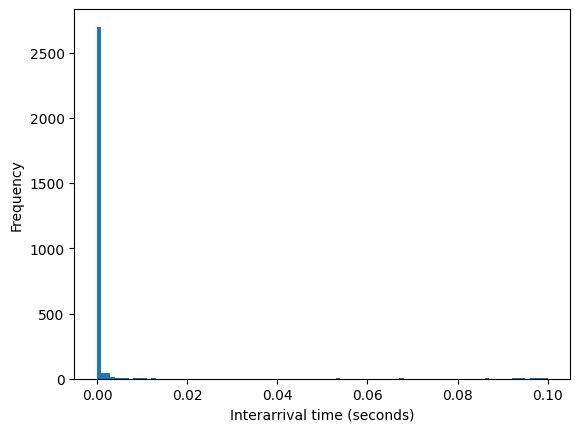

In [58]:
import numpy as np
import matplotlib.pyplot as plt

values = np.asarray(interarrival_times).flatten()
values = values[(values > 0) & (values <= 0.1)]

plt.hist(values, bins=100, range=(0, 0.1))
plt.xlabel("Interarrival time (seconds)")
plt.ylabel("Frequency")
plt.show()


Using 'stats' as the STATS variable: (4, 12)


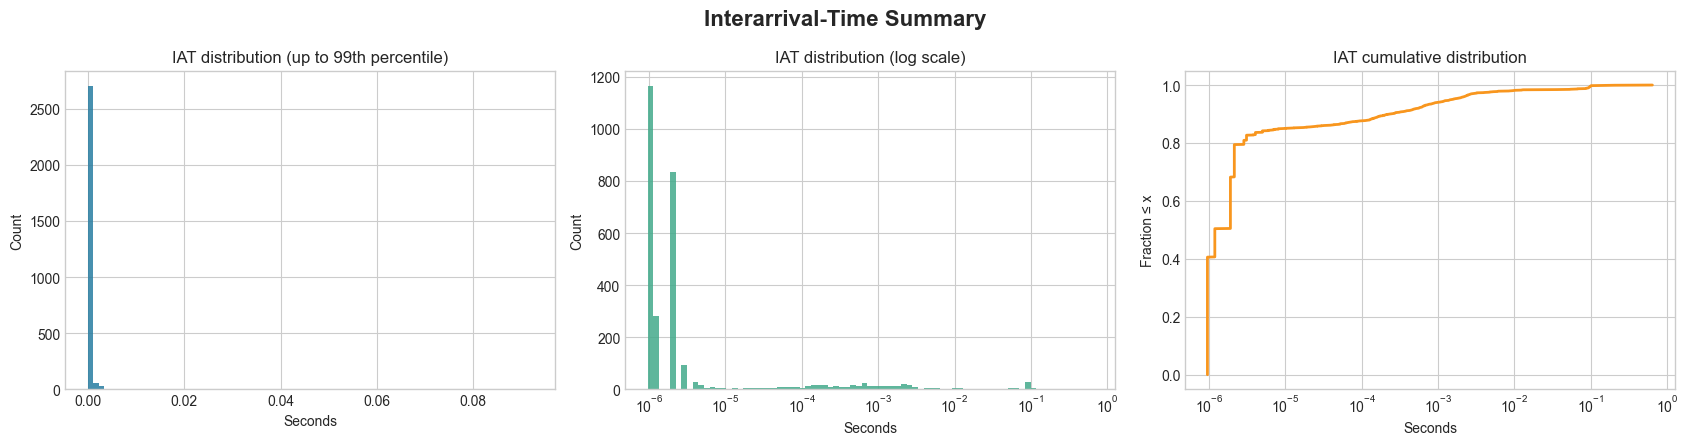

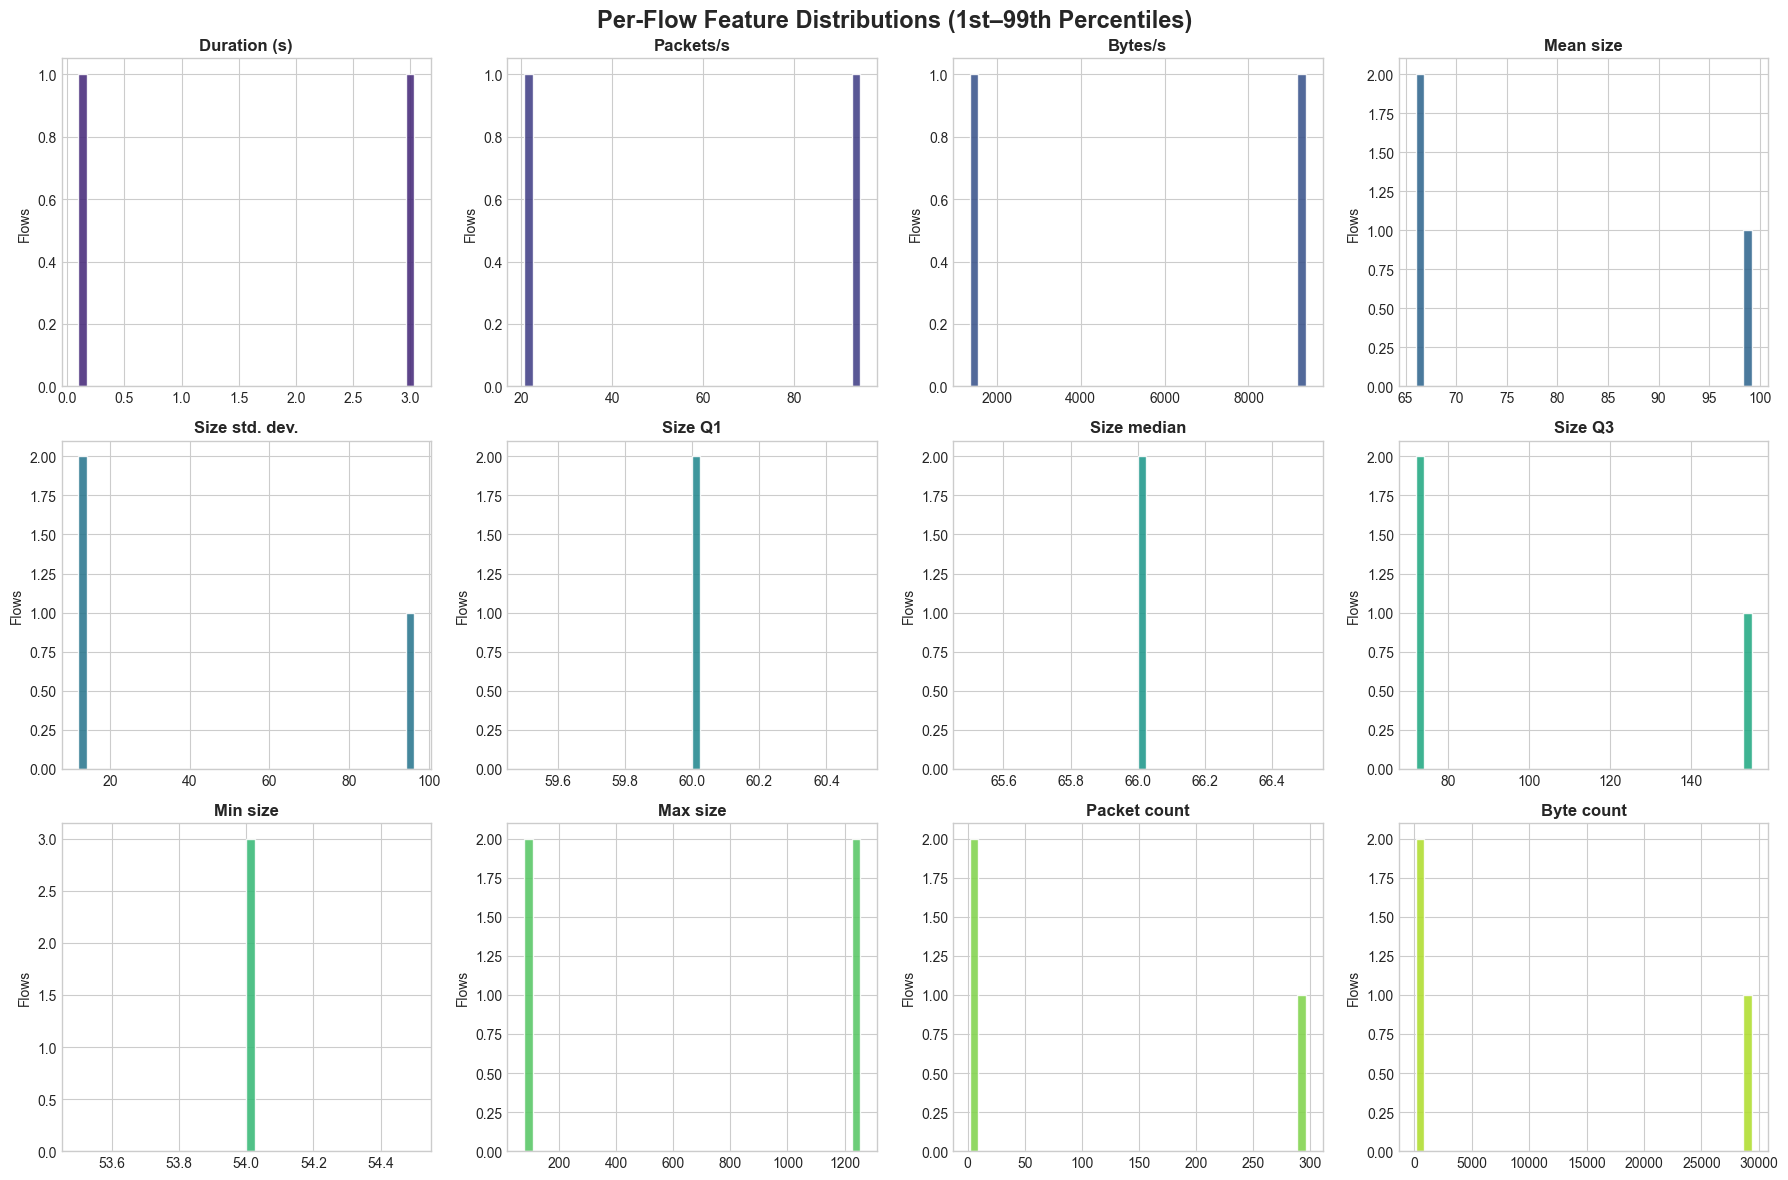

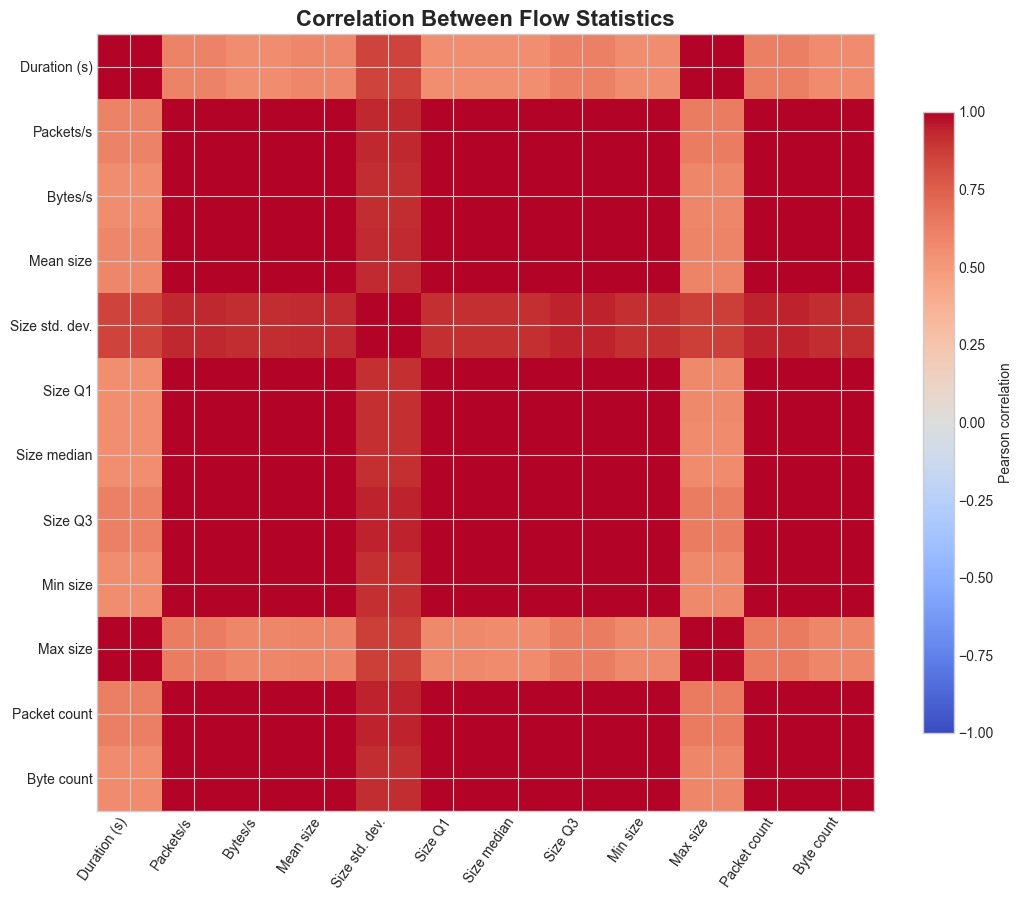

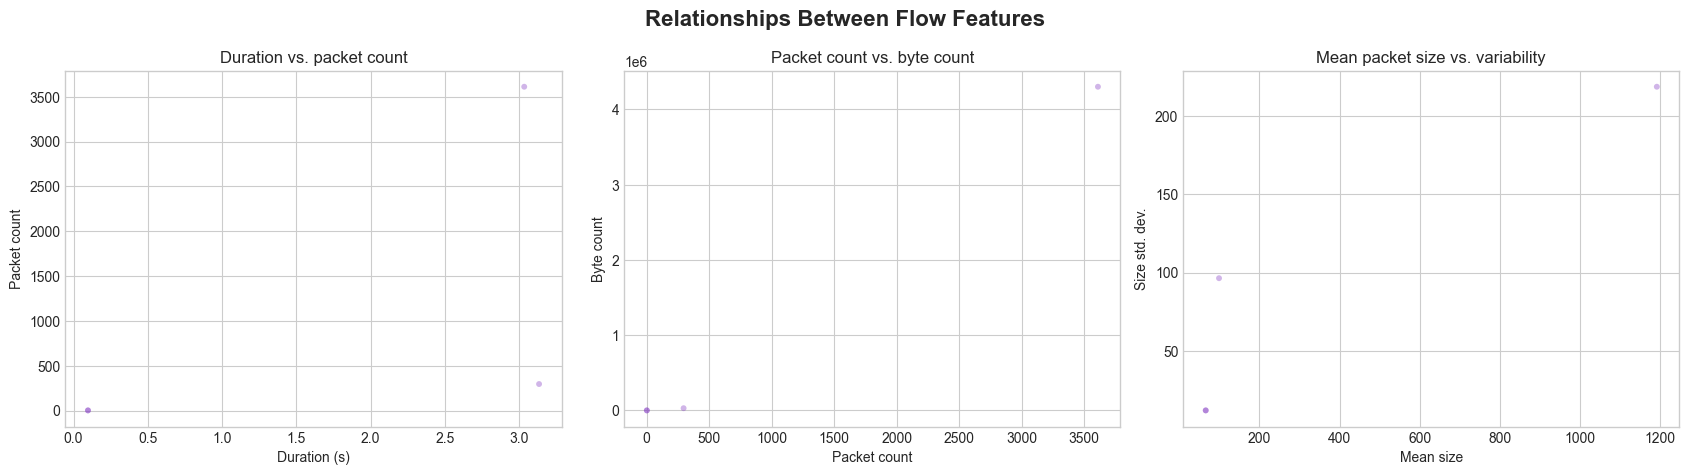

In [59]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
colors = plt.cm.viridis(np.linspace(0.12, 0.88, 12))

# IAT values: remove NetML's zero-padding and non-finite values.
iat = np.asarray(interarrival_times, dtype=float)
iat_positive = iat[np.isfinite(iat) & (iat > 0)]

# Find the NetML STATS variable created above (one row per flow, 12 columns).
_stats_matches = []
for _name, _value in list(globals().items()):
    if _name.startswith("_") or _name == "interarrival_times":
        continue
    try:
        _array = np.asarray(_value, dtype=float)
    except (TypeError, ValueError):
        continue
    if _array.ndim == 2 and _array.shape[1] == 12:
        _stats_matches.append((_name, _array))

if not _stats_matches:
    raise NameError("Could not find the STATS array from cell [46].")

stats_variable_name, stats_array = _stats_matches[-1]
print(f"Using {stats_variable_name!r} as the STATS variable: {stats_array.shape}")

stat_names = [
    "Duration (s)", "Packets/s", "Bytes/s", "Mean size",
    "Size std. dev.", "Size Q1", "Size median", "Size Q3",
    "Min size", "Max size", "Packet count", "Byte count",
]

# 1. Three complementary views of interarrival times.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
upper = np.quantile(iat_positive, 0.99)
visible_iat = iat_positive[iat_positive <= upper]
axes[0].hist(visible_iat, bins=80, color="#277da1", alpha=0.85)
axes[0].set(title="IAT distribution (up to 99th percentile)", xlabel="Seconds", ylabel="Count")

axes[1].hist(iat_positive, bins=np.logspace(np.log10(iat_positive.min()), np.log10(iat_positive.max()), 80), color="#43aa8b", alpha=0.85)
axes[1].set_xscale("log")
axes[1].set(title="IAT distribution (log scale)", xlabel="Seconds", ylabel="Count")

sorted_iat = np.sort(iat_positive)
axes[2].plot(sorted_iat, np.arange(1, len(sorted_iat) + 1) / len(sorted_iat), color="#f8961e", linewidth=2)
axes[2].set_xscale("log")
axes[2].set(title="IAT cumulative distribution", xlabel="Seconds", ylabel="Fraction ≤ x")
fig.suptitle("Interarrival-Time Summary", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()

# 2. Distribution of every STATS feature, clipping extreme outliers for readability.
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for index, (axis, name) in enumerate(zip(axes.flat, stat_names)):
    values = stats_array[:, index]
    values = values[np.isfinite(values)]
    low, high = np.quantile(values, [0.01, 0.99])
    visible = values[(values >= low) & (values <= high)]
    axis.hist(visible, bins=40, color=colors[index], alpha=0.88, edgecolor="white")
    axis.set_title(name, fontweight="bold")
    axis.set_ylabel("Flows")
fig.suptitle("Per-Flow Feature Distributions (1st–99th Percentiles)", fontsize=17, fontweight="bold")
fig.tight_layout()
plt.show()

# 3. Correlations between the 12 flow statistics.
correlation = np.corrcoef(stats_array, rowvar=False)
fig, axis = plt.subplots(figsize=(11, 9))
image = axis.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(12), stat_names, rotation=55, ha="right")
axis.set_yticks(range(12), stat_names)
axis.set_title("Correlation Between Flow Statistics", fontsize=16, fontweight="bold")
fig.colorbar(image, ax=axis, label="Pearson correlation", shrink=0.8)
fig.tight_layout()
plt.show()

# 4. Relationships among useful flow-level measurements.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
relationships = [
    (0, 10, "Duration vs. packet count"),
    (10, 11, "Packet count vs. byte count"),
    (3, 4, "Mean packet size vs. variability"),
]
for axis, (x_index, y_index, title) in zip(axes, relationships):
    x, y = stats_array[:, x_index], stats_array[:, y_index]
    mask = np.isfinite(x) & np.isfinite(y)
    axis.scatter(x[mask], y[mask], s=18, alpha=0.35, color="#7b2cbf", edgecolors="none")
    axis.set(xlabel=stat_names[x_index], ylabel=stat_names[y_index], title=title)
fig.suptitle("Relationships Between Flow Features", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()

### Other Features and Options

1. Try some of the other features in the `netml` library.

  Here are some of the other possibilities, which can be passed to the library:
  * IAT: A flow is represented as a timeseries of inter-arrival times between packets, i.e., elapsed time in seconds between any two packets in the flow.   
  *  STATS: A flow is represented as a set of statistical quantities. We choose ten of the most common such
statistics in the literature: flow duration, number of packets sent per second, number of bytes
per second, and various statistics on packet sizes within each flow: mean, standard deviation, inter-quartile range,
minimum, and maximum.
  * SIZE: A flow is represented as a timeseries of packet sizes in bytes, with one sample per packet. 
  * SAMP-NUM: A flow is partitioned into small intervals of equal length 𝛿𝑡, and the number of packets in each interval is recorded; thus, a flow is represented as a timeseries of packet counts in small time intervals, with one sample per time interval. Here, 𝛿𝑡 might be viewed as a choice of sampling rate for the timeseries, hence the nomenclature.
  * SAMP-SIZE: A flow is partitioned into time intervals of equal length 𝛿𝑡, and the total packet size (i.e., byte count) in each interval is recorded; thus, a flow is represented as a timeseries of byte counts in small time intervals, with one sample per time interval.
  

  
2. One of the challenges with providing packet traces to models involve ensuring that all feature vectors are of the same length. The `netml` libary will do that for you, but there are a number of different ways to solve the problem. What do some of the following options do?  Explore how different settings of the following affect the dimensionality of your resulting feature vector.

 * flow_ptks_thres
 * q_interval

## Thought Questions

What other features might you want to extract from packet captures that are not provided by the `netml` library?